## UIP_Darlytics Retail Company

#### IMPORTING LIBRARIES

In [1]:
#Import useful Libraries

#for numpy library
import numpy as np

#for loading DataFrame and some manipulation
import pandas as pd

#for visualization
import matplotlib.pyplot as plt

#for visualization
import seaborn as sns

#for splitting data into: training and testing data
from sklearn.model_selection import train_test_split

#to build the linear regression model
from sklearn.linear_model import LinearRegression 

#to be able to evaluate the built model to see how its performing using mean_absolute and mean_square errors
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

#to hide/ignore warnings
import warnings
warnings.simplefilter(action = "ignore")

#### IMPORTING DATASET

In [2]:
#import dataset (CSV)
m_drc = pd.read_csv(r"D:\2025\UTIVA_Internship\Superstore_SQL.csv", sep=",", encoding="ISO-8859-1")

#for all records: print(m_drc)
#for top 2 rows: m_drc.head(2)
#for last 2 rows: 
m_drc.tail(2)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
9991,9993,CA-2017-121258,26/02/2017,03/03/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.60,4,0.0,13.320
9992,9994,CA-2017-119914,04/05/2017,09/05/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.16,2,0.0,72.948


#### DATA CLEANING

In [3]:
#to check the shape (dimension) of the dataframe: 

print(m_drc.shape)
print()

#to check for null values: m_drc.isna().sum()
#to drop missing values (if necessary): df.dropna(inplace=True)

#to check for other info: 
m_drc.info()

(9993, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9993 non-null   int64  
 1   order_id       9993 non-null   object 
 2   order_date     9993 non-null   object 
 3   ship_date      9993 non-null   object 
 4   ship_mode      9993 non-null   object 
 5   customer_id    9993 non-null   object 
 6   customer_name  9993 non-null   object 
 7   segment        9993 non-null   object 
 8   country        9993 non-null   object 
 9   city           9993 non-null   object 
 10  state_         9993 non-null   object 
 11  postal_code    9993 non-null   int64  
 12  region         9993 non-null   object 
 13  product_id     9993 non-null   object 
 14  category       9993 non-null   object 
 15  sub_category   9993 non-null   object 
 16  product_name   9993 non-null   object 
 17  sales          9993 non-null   float64
 

In [4]:
#To correct wrong datatypes

#1_Convert Order Date and Ship Date to datetime
m_drc['order_date'] = pd.to_datetime(m_drc['order_date'], format='%d/%m/%Y', errors='coerce')
m_drc['ship_date'] = pd.to_datetime(m_drc['ship_date'], format='%d/%m/%Y', errors='coerce')


print(m_drc.dtypes)


row_id                    int64
order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
customer_id              object
customer_name            object
segment                  object
country                  object
city                     object
state_                   object
postal_code               int64
region                   object
product_id               object
category                 object
sub_category             object
product_name             object
sales                   float64
quantity                  int64
discount                float64
profit                  float64
dtype: object


In [5]:
#2_Convert categorical columns to category type (saves memory)

categorical_cols = ['ship_mode', 'segment', 'country', 'city', 'state_', 'region', 
                    'category', 'sub_category', 'product_name']
m_drc[categorical_cols] = m_drc[categorical_cols].astype('category')

print(m_drc.dtypes)

row_id                    int64
order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode              category
customer_id              object
customer_name            object
segment                category
country                category
city                   category
state_                 category
postal_code               int64
region                 category
product_id               object
category               category
sub_category           category
product_name           category
sales                   float64
quantity                  int64
discount                float64
profit                  float64
dtype: object


In [6]:
m_drc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9993 non-null   int64         
 1   order_id       9993 non-null   object        
 2   order_date     9993 non-null   datetime64[ns]
 3   ship_date      9993 non-null   datetime64[ns]
 4   ship_mode      9993 non-null   category      
 5   customer_id    9993 non-null   object        
 6   customer_name  9993 non-null   object        
 7   segment        9993 non-null   category      
 8   country        9993 non-null   category      
 9   city           9993 non-null   category      
 10  state_         9993 non-null   category      
 11  postal_code    9993 non-null   int64         
 12  region         9993 non-null   category      
 13  product_id     9993 non-null   object        
 14  category       9993 non-null   category      
 15  sub_category   9993 n

In [7]:
#Quick statistical analysis of dataset

m_drc.describe() 

,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit
count,9993.000000,9993,9993,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,4997.659161,2016-04-30 01:53:33.089162240,2016-05-04 00:53:19.039327488,55191.576403,229.852846,3.789753,0.156188,28.660971
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.000000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.731000
50%,4998.000000,2016-06-26 00:00:00,2016-06-29 00:00:00,56560.000000,54.480000,3.000000,0.200000,8.671000
75%,7496.000000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.264122,NaN,NaN,32065.074478,623.276074,2.225149,0.206457,234.271476


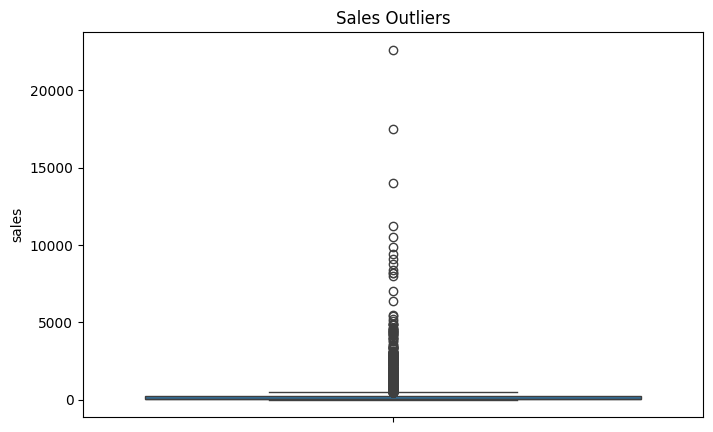

In [8]:
# Check for outliers in sales

plt.figure(figsize=(8,5))
sns.boxplot(y=m_drc['sales'])
plt.title("Sales Outliers")
plt.show()

#### DATA ANALYSIS

#### About the dataset

In [9]:
#Number of Entries

num_entries = m_drc.shape[0]                          #0 means x axis or rows
print(f"Number of entries: {num_entries}")


#Result: There are 9,993 records/rows of data

Number of entries: 9993


In [10]:
#Timeline of order

order_dates = m_drc["order_date"].nunique()
ship_dates = m_drc["ship_date"].nunique()
min_order_date, max_order_date = m_drc["order_date"].min(), m_drc["order_date"].max()
min_ship_date, max_ship_date = m_drc["ship_date"].min(), m_drc["ship_date"].max()

print(f"Order Dates: {order_dates} days ({min_order_date} - {max_order_date})")
print(f"Ship Dates: {ship_dates} days ({min_ship_date} - {max_ship_date})")

#Result: The record contains products ordered within 1237 days spanning 03/01/2014 - 30/12/2017
#        and products shipped within 1334 days spanning 07/01/2014 - 05/01/2018

Order Dates: 1237 days (2014-01-03 00:00:00 - 2017-12-30 00:00:00)
Ship Dates: 1334 days (2014-01-07 00:00:00 - 2018-01-05 00:00:00)


In [11]:
# Total Sales and Profit

total_sales = m_drc["sales"].sum()
total_profit = m_drc["profit"].sum()
total_quantity = m_drc["quantity"].sum()

print(f"Total Sales: ${total_sales:,.2f}, Total Net Profit: ${total_profit:,.2f}, Total products sold: {total_quantity:,.0f}")


#Result: Total Sales - $2,296,919.49
#        Total Profit - $286,409.08
#        Total Quantity - 37,871


Total Sales: $2,296,919.49, Total Net Profit: $286,409.08, Total products sold: 37,871


##### Quick overview of distinct categories

In [12]:
#Distinct Categories

ship_modes = m_drc["ship_mode"].nunique()
customers = m_drc["customer_id"].nunique()
segments = m_drc["segment"].nunique()
states = m_drc["state_"].nunique()
cities = m_drc["city"].nunique()
regions = m_drc["region"].nunique()
products = m_drc["product_id"].nunique()
categories = m_drc["category"].nunique()
sub_categories = m_drc["sub_category"].nunique()

print(f"Shipping Modes: {ship_modes}, Customers: {customers}, Segments: {segments}")
print(f"States: {states}, Cities: {cities}, Regions: {regions}")
print(f"Products: {products}, Categories: {categories}, Sub-Categories: {sub_categories}")


#Result: The shows distinct count of each categorical data

Shipping Modes: 4, Customers: 793, Segments: 3
States: 49, Cities: 531, Regions: 4
Products: 1862, Categories: 3, Sub-Categories: 17


##### To check unique (distinct) values

In [13]:
# How many (distinct) countries do we have?

m_drc["country"].unique()


#Result: one country: United States

['United States']
Categories (1, object): ['United States']

In [14]:
# How many (distinct) state_ do we have?

m_drc["state_"].unique()

#Result: 49 States

['Kentucky', 'California', 'Florida', 'North Carolina', 'Washington', ..., 'South Dakota', 'Idaho', 'North Dakota', 'Wyoming', 'West Virginia']
Length: 49
Categories (49, object): ['Alabama', 'Arizona', 'Arkansas', 'California', ..., 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

In [15]:
# How many (distinct) city do we have?

m_drc["city"].unique()

#Result: 531 Cities

['Henderson', 'Los Angeles', 'Fort Lauderdale', 'Concord', 'Seattle', ..., 'San Clemente', 'San Luis Obispo', 'Springdale', 'Lodi', 'Mason']
Length: 531
Categories (531, object): ['Aberdeen', 'Abilene', 'Akron', 'Albuquerque', ..., 'Yonkers', 'York', 'Yucaipa', 'Yuma']

In [16]:
# How many (distinct) customer_id do we have?

m_drc["customer_id"].unique()

array(['CG-12520', 'DV-13045', 'SO-20335', 'BH-11710', 'AA-10480',
       'IM-15070', 'HP-14815', 'PK-19075', 'AG-10270', 'ZD-21925',
       'KB-16585', 'SF-20065', 'EB-13870', 'EH-13945', 'TB-21520',
       'MA-17560', 'GH-14485', 'SN-20710', 'LC-16930', 'RA-19885',
       'ES-14080', 'ON-18715', 'PO-18865', 'LH-16900', 'DP-13000',
       'JM-15265', 'TB-21055', 'KM-16720', 'PS-18970', 'BS-11590',
       'KD-16270', 'HM-14980', 'JE-15745', 'KB-16600', 'SC-20770',
       'DN-13690', 'JC-16105', 'CS-12400', 'PG-18895', 'GM-14455',
       'JS-15685', 'KB-16315', 'RB-19705', 'PN-18775', 'KD-16345',
       'ER-13855', 'RB-19465', 'GZ-14470', 'LC-16870', 'JM-15250',
       'PA-19060', 'CV-12805', 'CL-12565', 'RC-19960', 'DK-13090',
       'GG-14650', 'SC-20725', 'AD-10180', 'PF-19165', 'TS-21610',
       'LS-16975', 'DW-13585', 'LC-16885', 'JD-15895', 'SH-19975',
       'SG-20080', 'HA-14920', 'MG-17680', 'JE-16165', 'TW-21025',
       'SP-20650', 'NK-18490', 'DB-13060', 'NP-18670', 'TT-210

In [17]:
# How many (distinct) product_id do we have?

m_drc["product_id"].unique()

array(['FUR-BO-10001798', 'FUR-CH-10000454', 'OFF-LA-10000240', ...,
       'OFF-AP-10003099', 'TEC-PH-10002645', 'OFF-ST-10001627'],
      dtype=object)

In [18]:
# How many (distinct) category do we have?

m_drc["category"].unique()

['Furniture', 'Office Supplies', 'Technology']
Categories (3, object): ['Furniture', 'Office Supplies', 'Technology']

In [19]:
# How many (distinct) sub_category do we have?

m_drc["sub_category"].unique()


['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage', ..., 'Envelopes', 'Fasteners', 'Supplies', 'Machines', 'Copiers']
Length: 17
Categories (17, object): ['Accessories', 'Appliances', 'Art', 'Binders', ..., 'Phones', 'Storage', 'Supplies', 'Tables']

In [20]:
# How many (distinct) ship_mode do we have?

m_drc["ship_mode"].unique()

['Second Class', 'Standard Class', 'First Class', 'Same Day']
Categories (4, object): ['First Class', 'Same Day', 'Second Class', 'Standard Class']

In [21]:
# How many (distinct) ORDER DATES do we have?

m_drc["order_date"].unique()


#Answer: one country (United States)

<DatetimeArray>
['2016-11-08 00:00:00', '2016-06-12 00:00:00', '2015-10-11 00:00:00',
 '2014-06-09 00:00:00', '2017-04-15 00:00:00', '2016-12-05 00:00:00',
 '2015-11-22 00:00:00', '2014-11-11 00:00:00', '2014-05-13 00:00:00',
 '2014-08-27 00:00:00',
 ...
 '2016-10-11 00:00:00', '2014-06-18 00:00:00', '2017-02-28 00:00:00',
 '2015-05-09 00:00:00', '2014-11-06 00:00:00', '2015-12-29 00:00:00',
 '2014-04-03 00:00:00', '2016-06-03 00:00:00', '2015-04-12 00:00:00',
 '2014-01-21 00:00:00']
Length: 1237, dtype: datetime64[ns]

In [22]:
# How many (distinct) SHIP DATES do we have?

m_drc["ship_date"].unique()


#Answer: one country (United States)

<DatetimeArray>
['2016-11-11 00:00:00', '2016-06-16 00:00:00', '2015-10-18 00:00:00',
 '2014-06-14 00:00:00', '2017-04-20 00:00:00', '2016-12-10 00:00:00',
 '2015-11-26 00:00:00', '2014-11-18 00:00:00', '2014-05-15 00:00:00',
 '2014-09-01 00:00:00',
 ...
 '2017-04-06 00:00:00', '2015-05-13 00:00:00', '2014-08-19 00:00:00',
 '2017-01-20 00:00:00', '2015-03-28 00:00:00', '2016-08-25 00:00:00',
 '2014-01-27 00:00:00', '2015-05-23 00:00:00', '2014-01-23 00:00:00',
 '2017-03-03 00:00:00']
Length: 1334, dtype: datetime64[ns]

#### Exploratory Data Analysis

In [23]:
#Total Revenue by Category and Region

# Compute total revenue by category and region
drc_catByreg_sales = m_drc.groupby(["region", "category"])["sales"].sum().reset_index()

# Rename column for clarity
drc_catByreg_sales.rename(columns={"sales": "total_revenue"}, inplace=True)

# Display top results
print(drc_catByreg_sales.head())

    region         category  total_revenue
0  Central        Furniture    163797.1638
1  Central  Office Supplies    167026.4150
2  Central       Technology    170416.3120
3     East        Furniture    208009.8320
4     East  Office Supplies    205516.0550


In [24]:
#What are the top-selling products and categories?

top_products = m_drc.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(5)
top_categories = m_drc.groupby("category")["sales"].sum().sort_values(ascending=False)

print(f"Top- selling products are: {top_products}")

print()

print(f"Top-selling categories are: {top_categories}")


#Result: Top-selling products by sales- Canon imageCLASS 2200 Advanced Copier generating $61, 599.82
#        Total-selling categories by sales - technology generating $836, 154. 03

Top- selling products are: product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: sales, dtype: float64

Top-selling categories are: category
Technology         836154.0330
Furniture          741718.4233
Office Supplies    719047.0320
Name: sales, dtype: float64


In [25]:
 #Which regions have the highest and lowest customer retention?

repeat_customers = m_drc.groupby(["customer_id", "region"]).size().reset_index(name="purchase_count")
retention_by_region = repeat_customers.groupby("region")["purchase_count"].mean().sort_values(ascending=False)

print(f"Regions Customer retention rate: {retention_by_region}")


#Result: The West has the highest customer retention rate
#        The South has the lowest customer retention rate

#Business Insight:

    #The West region has the most loyal customers, meaning strategies here work well.

    #The South region has the poorest retention, so further analysis is needed to understand why customers leave (e.g., poor service, pricing issues, product availability).

Regions Customer retention rate: region
West       4.039092
East       3.590164
Central    2.929382
South      2.042875
Name: purchase_count, dtype: float64


In [26]:
#What is the correlation between discounts and sales volume?

correlation = m_drc[['discount', 'sales']].corr()
print(f"Correlation: {correlation}")
print()

#What is the correlation between discounts and quantity volume?

correlation = m_drc[['discount', 'quantity']].corr()
print(f"Correlation: {correlation}")




#Result: The correlation coefficient between discount and sales is -0.028.
#        This value is very close to 0, indicating a very weak negative correlation.

#Result: The correlation coefficient between discount and quantity is 0.00868.
#        This value is also very close to 0, indicating a very weak negative correlation.

#Business Insight:
    #increasing or decreasing discounts does not significantly affect sales.
    #Other factors (such as product demand, seasonality, or marketing) likely play a bigger role in driving sales.

Correlation:           discount     sales
discount  1.000000 -0.028197
sales    -0.028197  1.000000

Correlation:           discount  quantity
discount   1.00000   0.00868
quantity   0.00868   1.00000


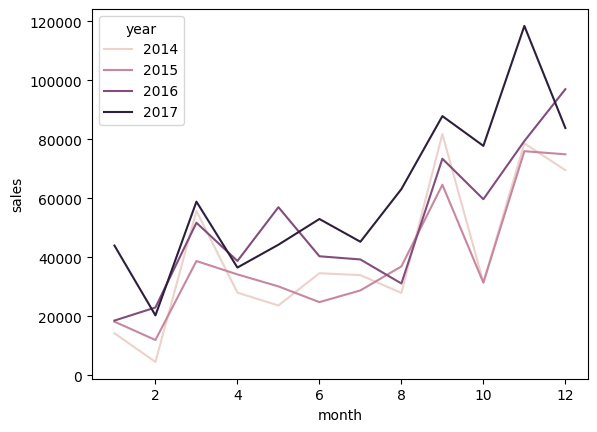

In [27]:
# Do certain months or seasons show a spike in sales?

m_drc["order_date"] = pd.to_datetime(m_drc["order_date"])
m_drc["month"] = m_drc["order_date"].dt.month
m_drc["year"] = m_drc["order_date"].dt.year

monthly_sales = m_drc.groupby(["year", "month"])["sales"].sum().reset_index()
sns.lineplot(x="month", y="sales", hue="year", data=monthly_sales)
plt.show()

#Result: The upward spike in january, march, september and november periods means a seasonal demand in this period.
            #The spike in January may be due to New Year promotions or post-holiday shopping, 
                #while the increase in March could be linked to end-of-quarter purchases, seasonal demand, or tax-related spending. 
            #The September surge might be influenced by back-to-school sales, fall season preparations, or early holiday shopping, 
                #whereas the November spike is likely driven by Black Friday, Cyber Monday, and early holiday shopping.

In [28]:
#What are the top-selling products and categories?

top_products = m_drc.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(5)
top_categories = m_drc.groupby("category")["sales"].sum().sort_values(ascending=False)

print(f"Top- selling products are: {top_products}")

print()

print(f"Top-selling categories are: {top_categories}")


#Result: Top-selling products by sales- Canon imageCLASS 2200 Advanced Copier generating $61, 599.82
#        Total-selling categories by sales - technology generating $836, 154. 03

Top- selling products are: product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: sales, dtype: float64

Top-selling categories are: category
Technology         836154.0330
Furniture          741718.4233
Office Supplies    719047.0320
Name: sales, dtype: float64


In [29]:
m_drcagg = m_drc.groupby('ship_mode').agg({'sales': ["mean", "min", "max", "count"], 
                                          'quantity': ["mean", "min", "max", "count"], 
                                          'discount': ["mean", "min", "max", "count"], 
                                          'profit': ["mean", "min", "max", "count"]
                                         })

m_drcagg.head()

sales                         quantity                \
                      mean    min       max count      mean min max count   
ship_mode                                                                   
First Class     228.497024  0.984  13999.96  1538  3.701560   1  14  1538   
Same Day        236.396179  0.556   7999.98   543  3.609576   1  14   543   
Second Class    236.089239  1.188   8749.95  1945  3.816452   1  14  1945   
Standard Class  227.574052  0.444  22638.48  5967  3.820178   1  14  5967   

                discount                     profit                        \
                    mean  min  max count       mean        min        max   
ship_mode                                                                   
First Class     0.164610  0.0  0.8  1538  31.839948 -2639.9912  6719.9808   
Same Day        0.152394  0.0  0.8   543  29.266591 -3839.9904  2229.0240   
Second Class    0.138895  0.0  0.8  1945  29.535545 -1862.3124  2799.9840   
Standard Class  0.160000  0.0  0.8  5967  27.501399 -6599.9780  8399.9760   

                      
               count  
ship_mode             
First Class     1538  
Same Day         543  
Second Class    1945  
Standard Class  5967

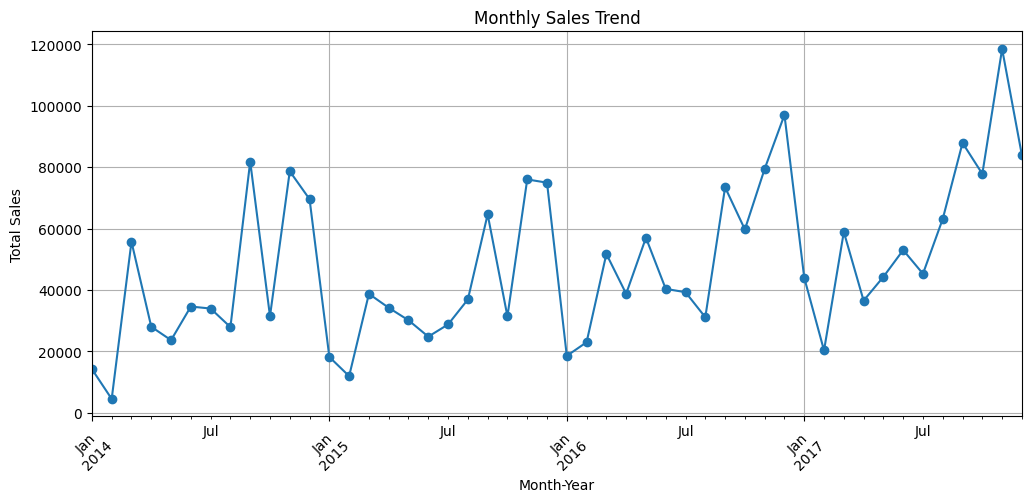

In [30]:
#Analyze overall sales trends over time.

m_drc['Month-Year'] = m_drc['order_date'].dt.to_period('M')

# Aggregate sales by month
monthly_sales = m_drc.groupby('Month-Year')['sales'].sum()

# Plot sales trend
plt.figure(figsize=(12,5))
monthly_sales.plot(marker="o")
plt.xlabel("Month-Year")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.grid()
plt.show()


#Result: There is an upward trend in sales over time (2014 -2017)

In [31]:
#Extract Month and Day of the Week to Find Patterns

m_drc['Month'] = m_drc['order_date'].dt.month
m_drc['Day of Week'] = m_drc['order_date'].dt.day_name()

# Average Sales by Month
monthly_avg_sales = m_drc.groupby('Month')['sales'].mean()

# Average Sales by Day of Week
weekday_avg_sales = m_drc.groupby('Day of Week')['sales'].mean()

# Sort days in order
weekday_avg_sales = weekday_avg_sales.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])


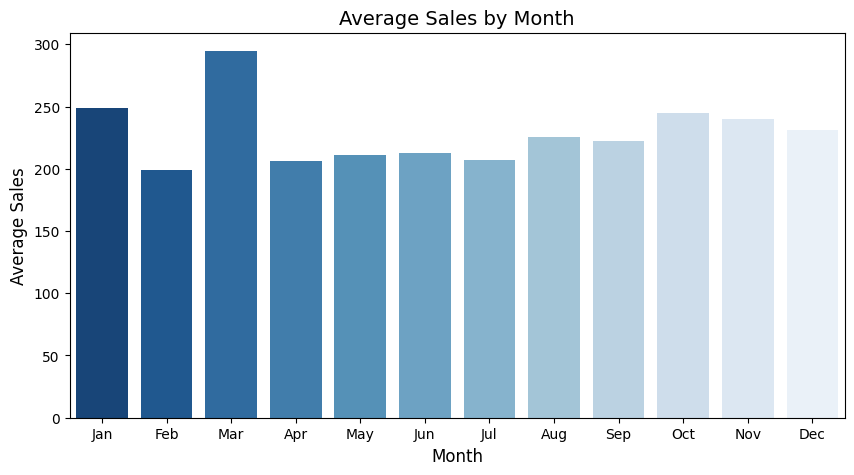

In [32]:
#Sales by Month

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_avg_sales.index, y=monthly_avg_sales.values, palette='Blues_r')
plt.title('Average Sales by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

#Result: On average, increase in sales mostly in january and march

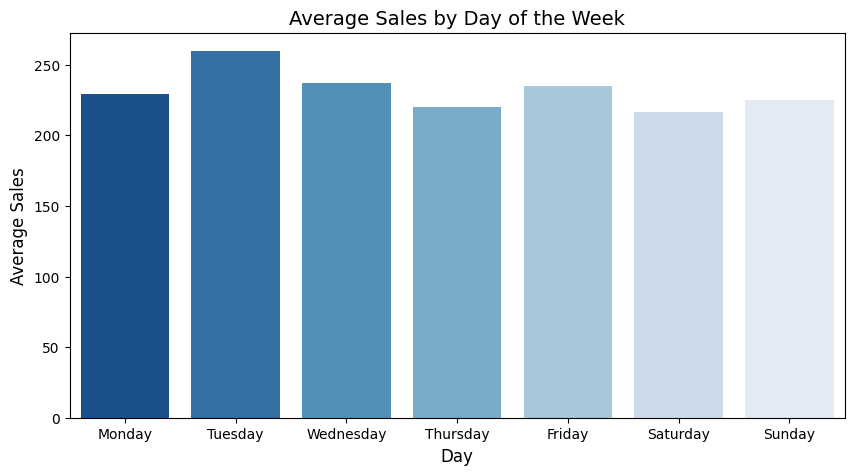

In [33]:
#Sales by Day of the Week

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_avg_sales.index, y=weekday_avg_sales.values, palette='Blues_r')
plt.title('Average Sales by Day of the Week', fontsize=14)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Average Sales', fontsize=12)
plt.show()


#Result: On average, increase in sales mostly on tuesdays and fridays

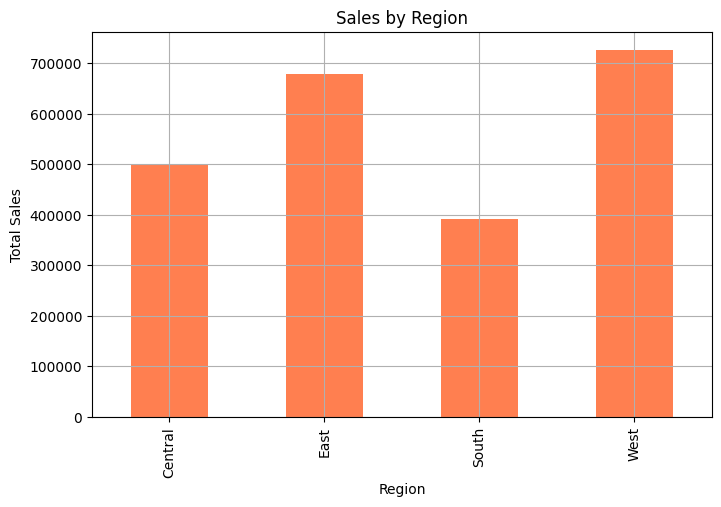

In [34]:
# Sales by region
region_sales = m_drc.groupby('region')['sales'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar", color="coral")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Sales by Region")
plt.grid()
plt.show()


#Result: On average, there are high sales in the west and East

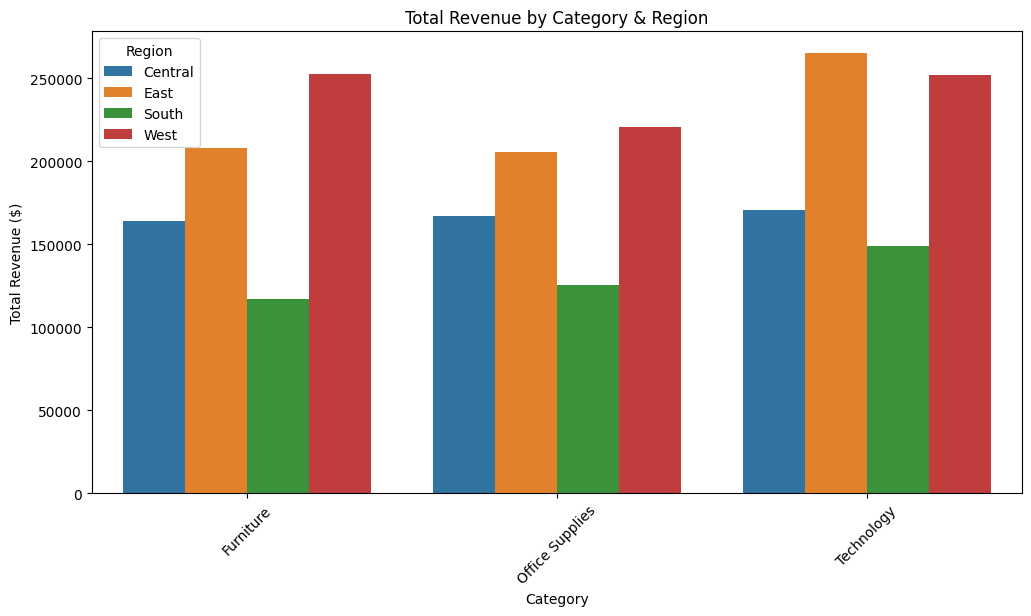

In [35]:
# to visualize Revenue Trends
# it shows revenue trends across categories and regions.

# Set plot style
plt.figure(figsize=(12,6))
sns.barplot(x="category", y="total_revenue", hue="region", data=drc_catByreg_sales)

# Add labels
plt.title("Total Revenue by Category & Region")
plt.xlabel("Category")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.show()


#### FORECASTING

             sales  discount  quantity    profit
sales     1.000000 -0.028197  0.200808  0.479067
discount -0.028197  1.000000  0.008680 -0.219481
quantity  0.200808  0.008680  1.000000  0.066241
profit    0.479067 -0.219481  0.066241  1.000000



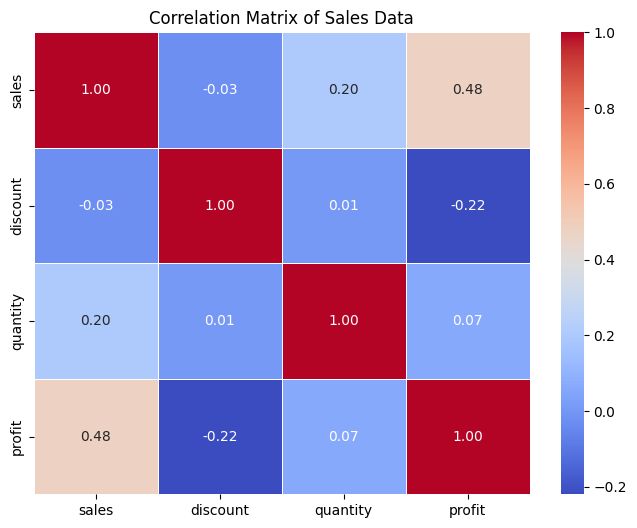

In [36]:
# To check correlations in numerical columns

numerical_cols = ["sales", "discount", "quantity", "profit"]  # Add more relevant features if available
correlation_matrix = m_drc[numerical_cols].corr()

# Display correlation matrix
print(correlation_matrix)
print()


# Set the figure size
plt.figure(figsize=(8, 6))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add title
plt.title("Correlation Matrix of Sales Data")

# Show plot
plt.show()

#Result: "sales", "discount", "quantity", and "profit" are not really correlated and might not influence one another


##### Linear Regression

In [37]:
#How do different factors discount impact future sales?

#Using a regression model

#Creating the Model
model = LinearRegression()


#Preparing our data

#what helps to predict
X = m_drc[["discount"]]       #ensure its a 2D array [[]] 

#what we intend to predict
y = m_drc["sales"]

#splitting the dataset into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#test_size means 20% test data
#random state: 42 (standard value), ensures we get same observation in train and test everytime we run random state at a certain number

#to check the split
print(X_train.shape)
print(X_test.shape)

#train mdf_model with the training dataset
#using the fit model in LinearRegression
model.fit(X_train,y_train)


#using the trained model to make predictions ith the test data

y_pred = model.predict(X_test)



#Evaluting the model using Mean Absolute Error (MAE)

m_drc_Mae = mean_absolute_error(y_test, y_pred)
print("The Mean Absolute Error is", m_drc_Mae)


m_drc_Mse = mean_squared_error(y_test, y_pred)
print("The Mean Squared Error is", m_drc_Mse)


#Result:
            #The Mean Absolute Error is 287.4430771059474
            #The Mean Squared Error is 599280.2621245144

#Business Insight:
            #Since your MAE is quite high, and MSE is very large, your model's ability to predict sales using only discounts as a predictor is poor.


(7994, 1)
(1999, 1)
The Mean Absolute Error is 287.4430771059474
The Mean Squared Error is 599280.2621245144


In [38]:
#How do different factors quantity impact future sales?

#Using a regression model

#Creating the Model
model = LinearRegression()


#Preparing our data

#what helps to predict
X = m_drc[["quantity"]]       #ensure its a 2D array [[]] 

#what we intend to predict
y = m_drc["sales"]

#splitting the dataset into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#test_size means 20% test data
#random state: 42 (standard value), ensures we get same observation in train and test everytime we run random state at a certain number

#to check the split
print(X_train.shape)
print(X_test.shape)

#train mdf_model with the training dataset
#using the fit model in LinearRegression
model.fit(X_train,y_train)


#using the trained model to make predictions ith the test data

y_pred = model.predict(X_test)



#Evaluting the model using Mean Absolute Error (MAE)

m_drc_Mae = mean_absolute_error(y_test, y_pred)
print("The Mean Absolute Error is", m_drc_Mae)


m_drc_Mse = mean_squared_error(y_test, y_pred)
print("The Mean Squared Error is", m_drc_Mse)


#Result:
            #The Mean Absolute Error is 287.4430771059474
            #The Mean Squared Error is 599280.2621245144

#Business Insight:
            #Since your MAE is quite high, and MSE is very large, your model's ability to predict sales using only quantity as a predictor is poor.


(7994, 1)
(1999, 1)
The Mean Absolute Error is 273.48176897848253
The Mean Squared Error is 578334.9097122839


In [39]:
#How do different factors profit) impact future sales?

#Using a regression model

#Creating the Model
model = LinearRegression()


#Preparing our data

#what helps to predict
X = m_drc[["profit"]]       #ensure its a 2D array [[]] 

#what we intend to predict
y = m_drc["sales"]

#splitting the dataset into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#test_size means 20% test data
#random state: 42 (standard value), ensures we get same observation in train and test everytime we run random state at a certain number

#to check the split
print(X_train.shape)
print(X_test.shape)

#train mdf_model with the training dataset
#using the fit model in LinearRegression
model.fit(X_train,y_train)


#using the trained model to make predictions ith the test data

y_pred = model.predict(X_test)



#Evaluting the model using Mean Absolute Error (MAE)

m_drc_Mae = mean_absolute_error(y_test, y_pred)
print("The Mean Absolute Error is", m_drc_Mae)


m_drc_Mse = mean_squared_error(y_test, y_pred)
print("The Mean Squared Error is", m_drc_Mse)


#Result:
            #The Mean Absolute Error is 287.4430771059474
            #The Mean Squared Error is 599280.2621245144

#Business Insight:
            #Since your MAE is quite high, and MSE is very large, your model's ability to predict sales using only profit as a predictor is poor.


(7994, 1)
(1999, 1)
The Mean Absolute Error is 252.00997465643093
The Mean Squared Error is 813469.7236002317


In [40]:
#Testing the Model

ny_pred = model.predict([[300000]])
ny_pred


#Result: A profit of 300,000 can be obtained if a sale of about $16, 355, 967.17 is made.

array([527791.16761713])

In [41]:
#What is the expected revenue growth rate based on past trends?

m_drc["order_date"] = pd.to_datetime(m_drc["order_date"])
m_drc["year"] = m_drc["order_date"].dt.year

annual_sales = m_drc.groupby("year")["sales"].sum().reset_index()
annual_sales["log_sales"] = np.log(annual_sales["sales"])

from sklearn.linear_model import LinearRegression

X = annual_sales[["year"]]
y = annual_sales["log_sales"]

model = LinearRegression()
model.fit(X, y)

growth_rate = model.coef_[0]  # Annual growth rate
print(f"Expected annual growth rate: {round(growth_rate * 100, 2)}%")


#Result: based on historical sales trends, the company's revenue is expected to grow by approximately 15.05% per year on average.

Expected annual growth rate: 15.05%


In [42]:
print("Well done! Dami")

Well done! Dami
